<a href="https://colab.research.google.com/github/Yusuffff101/Yusuf-Bootwala/blob/main/EDA_Phase1%26Pahse2_Employee_Attrition_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Employee Attrition — EDA Course Project (Phase 1)

**Dataset:** [Employee Attrition.csv](https://raw.githubusercontent.com/salemprakash/EDA/main/Data/Employee%20Attrition.csv)

**Phase 1 tasks covered in this notebook:**
1. Loading the dataset
2. Basic statistical analysis
3. Handling missing data
4. Data cleaning
5. Data transformation
6. Univariate analysis (≥ 3 visualizations)
7. Bivariate analysis (≥ 3 visualizations)
8. Multivariate analysis (≥ 3 visualizations)




## 0. Import Libraries

In [1]:
# Core libraries for data handling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

pd.set_option("display.max_columns", None)


## 1. Loading the Dataset



In [2]:
url = "https://raw.githubusercontent.com/salemprakash/EDA/main/Data/Employee%20Attrition.csv"
df = pd.read_csv(url)

print("Shape of dataset (rows, columns):", df.shape)
df.head()


Shape of dataset (rows, columns): (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [3]:
# Quick structural overview: column names, non-null counts, and data types
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

## 2. Basic Statistical Analysis

Summary statistics for numeric and categorical columns to understand the central
tendency, spread, and distribution of the data.


In [4]:
# Descriptive statistics for all NUMERIC columns
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [5]:
# Descriptive statistics for all CATEGORICAL (object) columns
df.describe(include="object").T


,count,unique,top,freq
Attrition,1470,2,No,1233
BusinessTravel,1470,3,Travel_Rarely,1043
Department,1470,3,Research & Development,961
EducationField,1470,6,Life Sciences,606
Gender,1470,2,Male,882
JobRole,1470,9,Sales Executive,326
MaritalStatus,1470,3,Married,673
Over18,1470,1,Y,1470
OverTime,1470,2,No,1054


In [6]:
# Target variable distribution (class balance check)
print(df["Attrition"].value_counts())
print()
print(df["Attrition"].value_counts(normalize=True).round(3) * 100, "%")


Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition
No     83.9
Yes    16.1
Name: proportion, dtype: float64 %


## 3. Handling Missing Data

Check for missing/null values across all columns and decide how to treat them.


In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_summary = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct.round(2)})
missing_summary = missing_summary[missing_summary["Missing Count"] > 0].sort_values("Missing Count", ascending=False)

if missing_summary.empty:
    print("No missing values found in the dataset.")
else:
    print(missing_summary)


No missing values found in the dataset.


In [8]:
# Defensive handling in case missing values ARE found when re-run on an updated dataset:
# - Numeric columns  -> fill with median (robust to outliers)
# - Categorical columns -> fill with mode (most frequent category)

num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include="object").columns

for c in num_cols:
    if df[c].isnull().sum() > 0:
        df[c] = df[c].fillna(df[c].median())

for c in cat_cols:
    if df[c].isnull().sum() > 0:
        df[c] = df[c].fillna(df[c].mode()[0])

print("Missing values remaining after handling:", df.isnull().sum().sum())


Missing values remaining after handling: 0


## 4. Data Cleaning

- Remove duplicate rows (if any)
- Drop columns that carry no analytical value (constant across all rows)
- Fix data types where appropriate


In [9]:
# Check and remove duplicate rows
dup_count = df.duplicated().sum()
print("Number of duplicate rows:", dup_count)
df = df.drop_duplicates()


Number of duplicate rows: 0


In [10]:
# Identify columns with only ONE unique value — they add no information for EDA/modeling
constant_cols = [c for c in df.columns if df[c].nunique() == 1]
print("Constant (non-informative) columns:", constant_cols)

df_clean = df.drop(columns=constant_cols)
print("\nShape after dropping constant columns:", df_clean.shape)


Constant (non-informative) columns: ['EmployeeCount', 'Over18', 'StandardHours']

Shape after dropping constant columns: (1470, 32)


In [11]:
# Sanity check: unique values for a few categorical columns (helps spot inconsistent labels)
for c in ["Attrition", "BusinessTravel", "Department", "Gender", "OverTime"]:
    print(f"{c}: {df_clean[c].unique()}")


Attrition: ['Yes' 'No']
BusinessTravel: ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']
Department: ['Sales' 'Research & Development' 'Human Resources']
Gender: ['Female' 'Male']
OverTime: ['Yes' 'No']


## 5. Data Transformation

- Encode the binary target (`Attrition`) as 0/1 for easier plotting and future modeling
- Create a few readable derived features (age groups, income in K) used later in the analysis
- Encode other Yes/No columns similarly


In [12]:
# Binary-encode Yes/No columns
binary_map = {"Yes": 1, "No": 0}
df_clean["Attrition_Flag"] = df_clean["Attrition"].map(binary_map)
df_clean["OverTime_Flag"] = df_clean["OverTime"].map(binary_map)

# Feature engineering: bucket Age into readable groups
bins = [17, 25, 35, 45, 55, 65]
labels = ["18-25", "26-35", "36-45", "46-55", "56-65"]
df_clean["AgeGroup"] = pd.cut(df_clean["Age"], bins=bins, labels=labels)

# Feature engineering: Monthly income expressed in thousands (easier to read on plots)
df_clean["MonthlyIncome_K"] = (df_clean["MonthlyIncome"] / 1000).round(1)

df_clean[["Age", "AgeGroup", "MonthlyIncome", "MonthlyIncome_K", "Attrition", "Attrition_Flag", "OverTime", "OverTime_Flag"]].head()


,Age,AgeGroup,MonthlyIncome,MonthlyIncome_K,Attrition,Attrition_Flag,OverTime,OverTime_Flag
0,41,36-45,5993,6.0,Yes,1,Yes,1
1,49,46-55,5130,5.1,No,0,No,0
2,37,36-45,2090,2.1,Yes,1,Yes,1
3,33,26-35,2909,2.9,No,0,Yes,1
4,27,26-35,3468,3.5,No,0,No,0


In [13]:
# Final cleaned & transformed dataset used for the rest of the analysis
df_final = df_clean.copy()
df_final.shape


(1470, 36)

## 6. Univariate Analysis
Examining the distribution of individual variables (minimum 3 visualizations).


### 6.1 Distribution of Employee Age

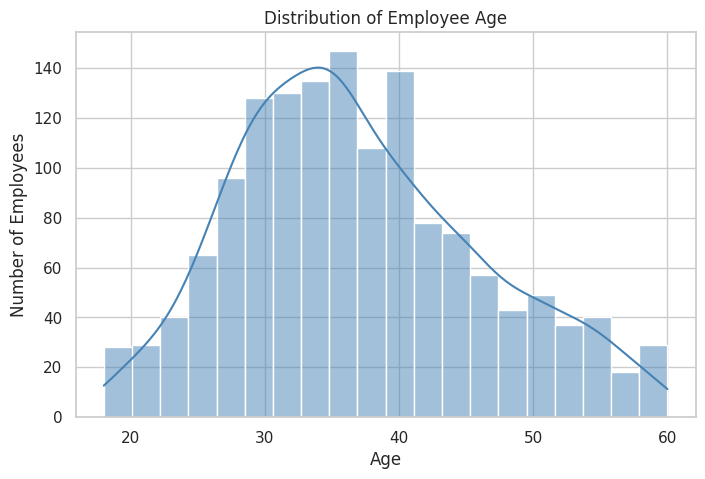

In [14]:
plt.figure()
sns.histplot(df_final["Age"], bins=20, kde=True, color="steelblue")
plt.title("Distribution of Employee Age")
plt.xlabel("Age")
plt.ylabel("Number of Employees")
plt.show()


### 6.2 Attrition Count (Target Variable)

/tmp/ipykernel_3178/75770817.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_final, x="Attrition", palette="Set2")


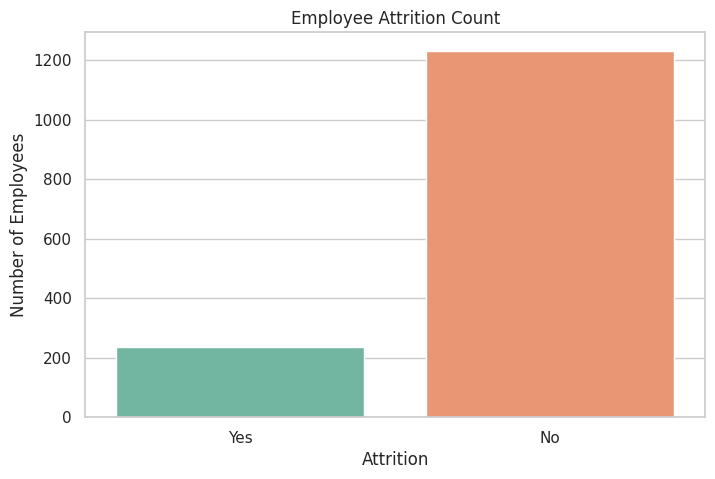

In [15]:
plt.figure()
sns.countplot(data=df_final, x="Attrition", palette="Set2")
plt.title("Employee Attrition Count")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")
plt.show()


### 6.3 Spread of Monthly Income

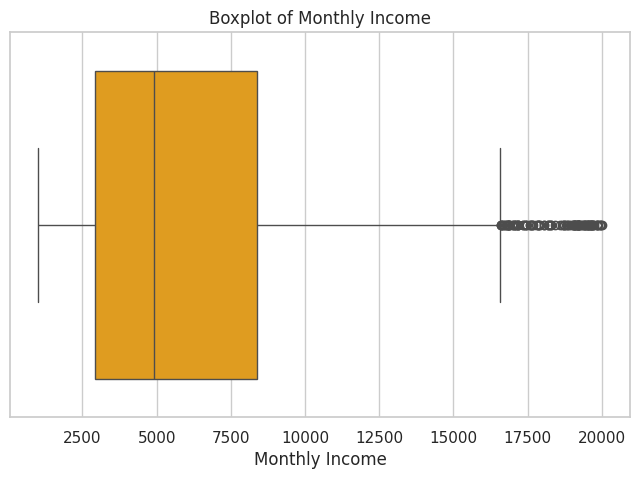

In [16]:
plt.figure()
sns.boxplot(data=df_final, x="MonthlyIncome", color="orange")
plt.title("Boxplot of Monthly Income")
plt.xlabel("Monthly Income")
plt.show()


### 6.4 Job Role Frequency (bonus)

/tmp/ipykernel_3178/882138231.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_final, y="JobRole", order=order, palette="viridis")


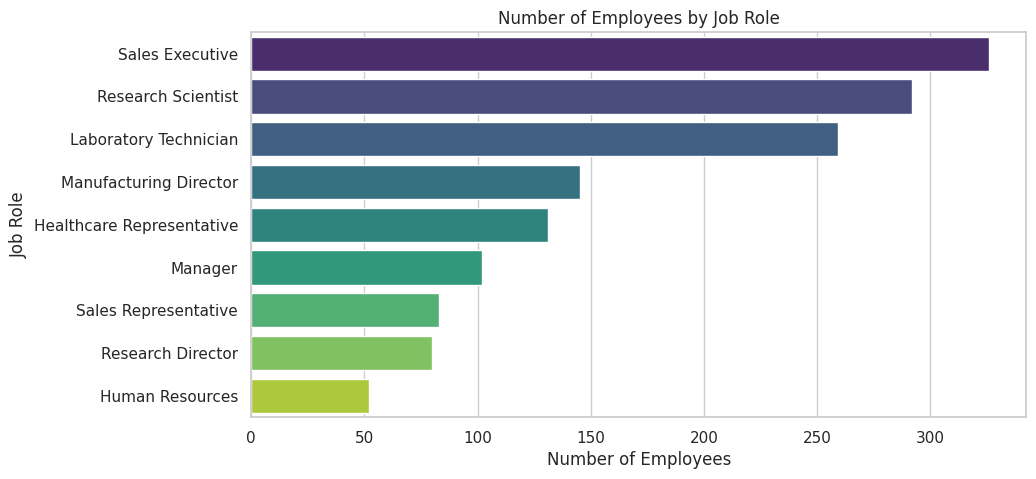

In [17]:
plt.figure(figsize=(10, 5))
order = df_final["JobRole"].value_counts().index
sns.countplot(data=df_final, y="JobRole", order=order, palette="viridis")
plt.title("Number of Employees by Job Role")
plt.xlabel("Number of Employees")
plt.ylabel("Job Role")
plt.show()


## 7. Bivariate Analysis
Examining relationships between pairs of variables (minimum 3 visualizations).


### 7.1 Monthly Income vs Attrition

/tmp/ipykernel_3178/3047947254.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x="Attrition", y="MonthlyIncome", palette="Set3")


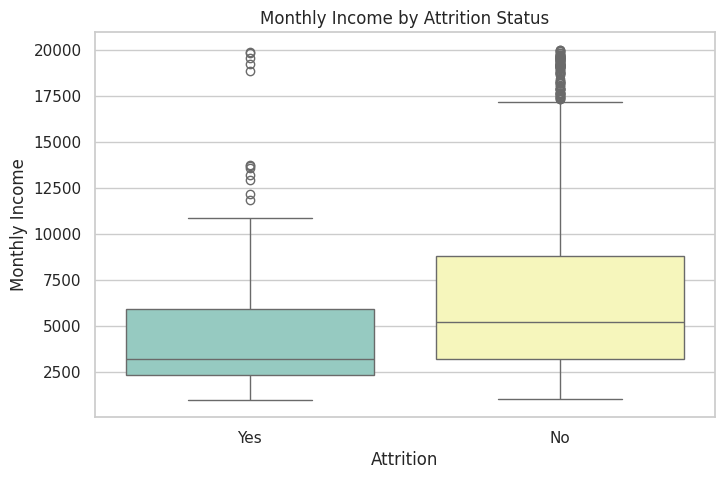

In [18]:
plt.figure()
sns.boxplot(data=df_final, x="Attrition", y="MonthlyIncome", palette="Set3")
plt.title("Monthly Income by Attrition Status")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.show()


### 7.2 OverTime vs Attrition

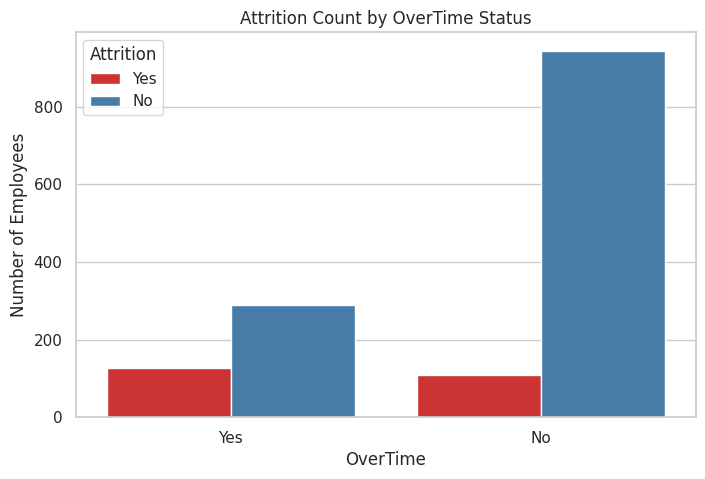

In [19]:
plt.figure()
sns.countplot(data=df_final, x="OverTime", hue="Attrition", palette="Set1")
plt.title("Attrition Count by OverTime Status")
plt.xlabel("OverTime")
plt.ylabel("Number of Employees")
plt.show()


### 7.3 Age vs Monthly Income

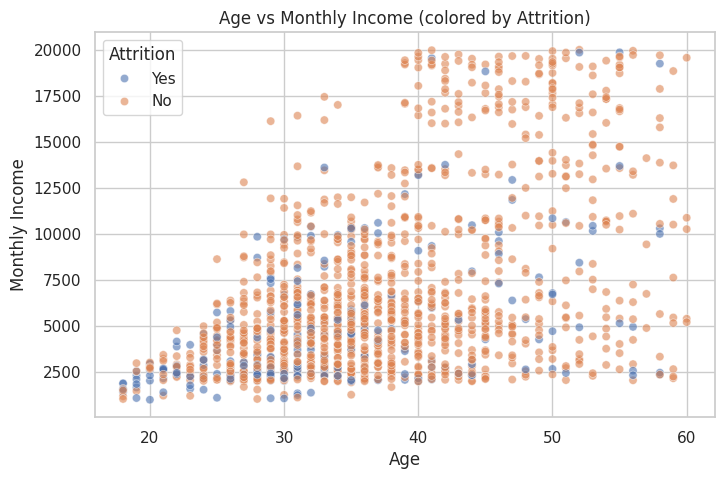

In [20]:
plt.figure()
sns.scatterplot(data=df_final, x="Age", y="MonthlyIncome", hue="Attrition", alpha=0.6)
plt.title("Age vs Monthly Income (colored by Attrition)")
plt.xlabel("Age")
plt.ylabel("Monthly Income")
plt.show()


### 7.4 Job Satisfaction vs Attrition (bonus)

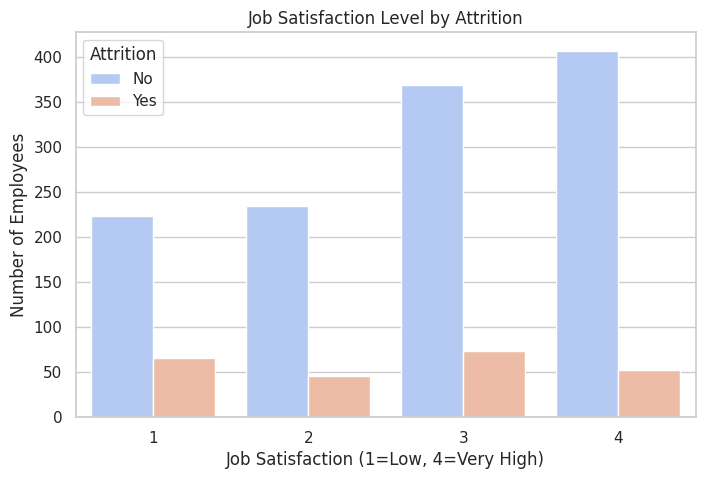

In [21]:
plt.figure()
sns.countplot(data=df_final, x="JobSatisfaction", hue="Attrition", palette="coolwarm")
plt.title("Job Satisfaction Level by Attrition")
plt.xlabel("Job Satisfaction (1=Low, 4=Very High)")
plt.ylabel("Number of Employees")
plt.show()


## 8. Multivariate Analysis
Examining relationships among three or more variables at once (minimum 3 visualizations).


### 8.1 Correlation Heatmap of Numeric Features

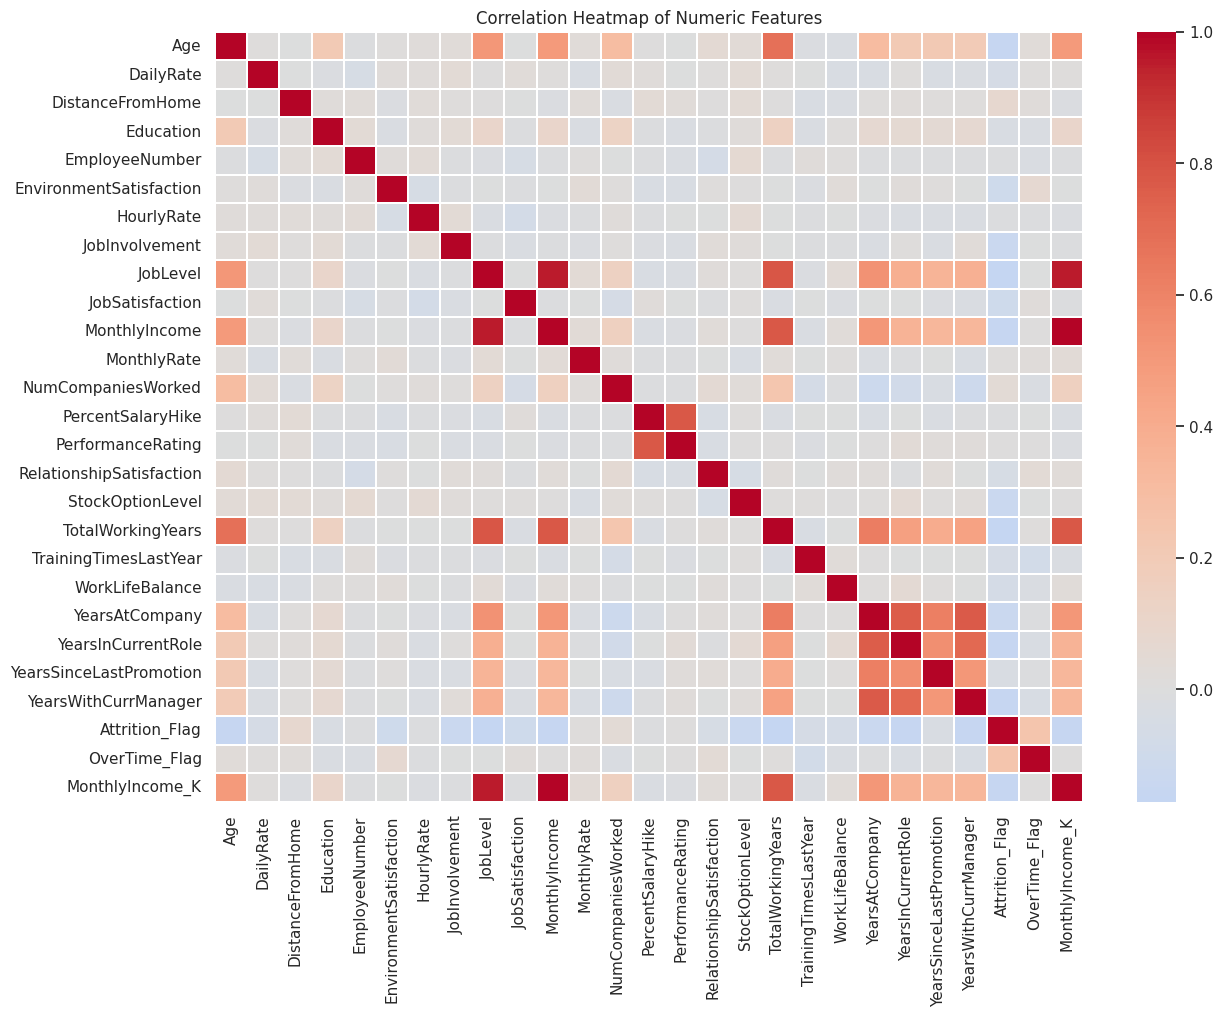

In [22]:
plt.figure(figsize=(14, 10))
numeric_df = df_final.select_dtypes(include=np.number)
corr = numeric_df.corr()
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.3)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()


### 8.2 Monthly Income by Department and Attrition

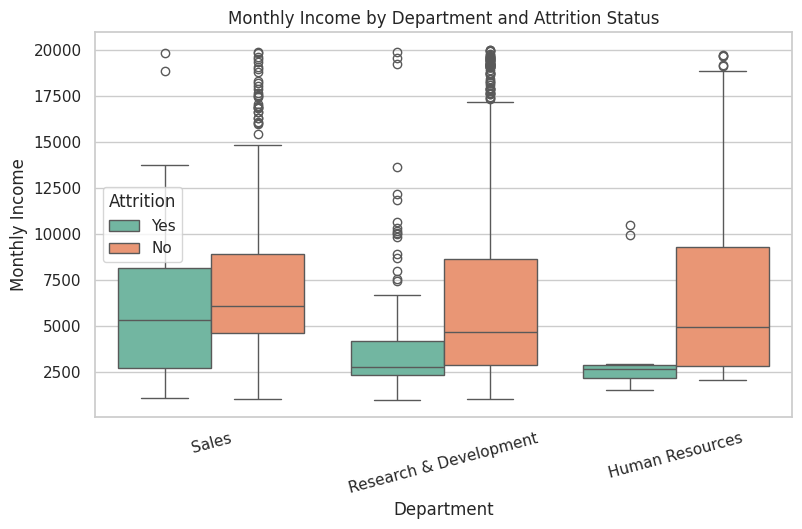

In [23]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df_final, x="Department", y="MonthlyIncome", hue="Attrition", palette="Set2")
plt.title("Monthly Income by Department and Attrition Status")
plt.xlabel("Department")
plt.ylabel("Monthly Income")
plt.xticks(rotation=15)
plt.show()


### 8.3 Age, Monthly Income and Attrition (pairwise relationships)

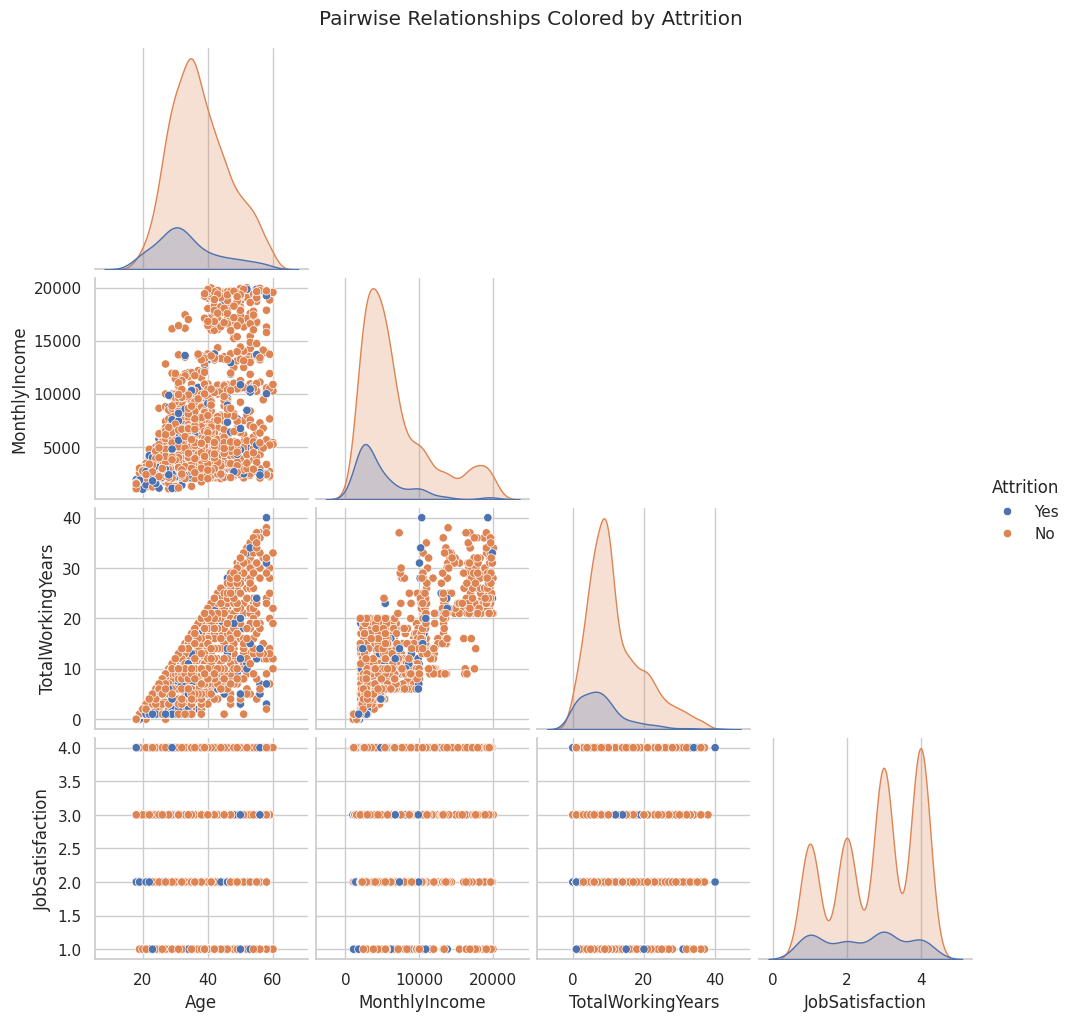

In [24]:
subset_cols = ["Age", "MonthlyIncome", "TotalWorkingYears", "JobSatisfaction", "Attrition"]
sns.pairplot(df_final[subset_cols], hue="Attrition", diag_kind="kde", corner=True)
plt.suptitle("Pairwise Relationships Colored by Attrition", y=1.02)
plt.show()


### 8.4 Attrition Rate by Department and Gender (bonus)

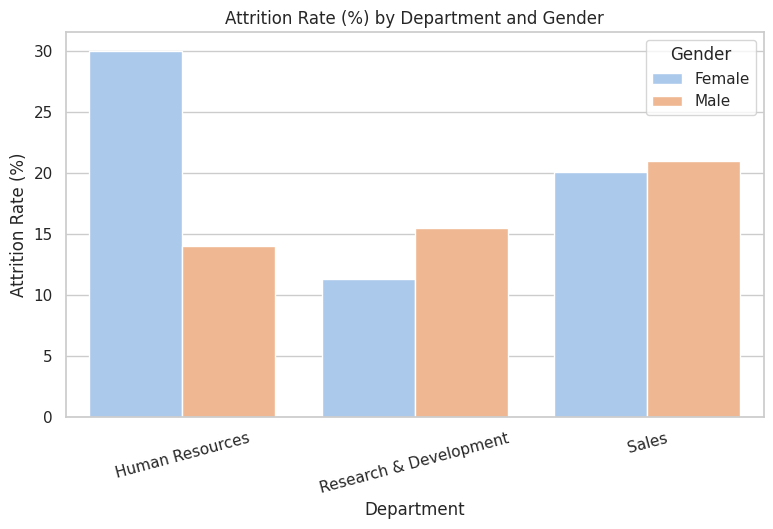

In [25]:
grouped = (
    df_final.groupby(["Department", "Gender"])["Attrition_Flag"]
    .mean()
    .mul(100)
    .round(1)
    .reset_index(name="AttritionRate(%)")
)

plt.figure(figsize=(9, 5))
sns.barplot(data=grouped, x="Department", y="AttritionRate(%)", hue="Gender", palette="pastel")
plt.title("Attrition Rate (%) by Department and Gender")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=15)
plt.show()


## 9. Summary of Findings (Phase 1)

- The dataset contains **1470 employee records** with **35 original columns**; no missing values were found.
- Three constant columns (`EmployeeCount`, `StandardHours`, `Over18`) carried no analytical value and were dropped.
- Overall attrition rate is roughly **16%**, indicating class imbalance in the target variable.
- Employees who work **OverTime** show a noticeably higher attrition rate than those who don't.
- **Lower monthly income** and **lower job satisfaction** are visibly associated with higher attrition.
- The correlation heatmap highlights strong relationships between tenure-related features
  (e.g., `YearsAtCompany`, `YearsInCurrentRole`, `YearsWithCurrManager`).

*These observations will be explored further with statistical testing and modeling in later phases of the project.*


---
# Phase 2 — Statistical Analysis (1D / 2D / 3D) and Clustering

**Phase 2 tasks covered below:**
1. 1D (Univariate) Statistical Analysis
2. 2D (Bivariate) Statistical Analysis
3. 3D (Multivariate) Statistical Analysis
4. K-Means Clustering
5. Hierarchical Clustering

This section builds directly on `df_final`, the cleaned and transformed dataset produced in Phase 1.
Run the Phase 1 cells above first so that `df_final` exists in memory.


## Import Additional Libraries for Phase 2

In [26]:
# Statistics
from scipy import stats
from scipy.stats import shapiro, pearsonr, spearmanr, chi2_contingency, f_oneway, ttest_ind

# 3D plotting
from mpl_toolkits.mplot3d import Axes3D

# Clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

print("Phase 2 libraries loaded successfully.")


Phase 2 libraries loaded successfully.


## 1. 1D (Univariate) Statistical Analysis

Going beyond simple `describe()`, this section formally characterizes the **shape and
distribution** of individual numeric variables: central tendency, dispersion, skewness,
kurtosis, and normality.


### 1.1 Central Tendency, Dispersion, Skewness, and Kurtosis

In [27]:
numeric_cols_1d = ["Age", "MonthlyIncome", "TotalWorkingYears", "YearsAtCompany",
                    "DistanceFromHome", "JobSatisfaction"]

summary_1d = pd.DataFrame({
    "Mean": df_final[numeric_cols_1d].mean(),
    "Median": df_final[numeric_cols_1d].median(),
    "Mode": df_final[numeric_cols_1d].mode().iloc[0],
    "Std Dev": df_final[numeric_cols_1d].std(),
    "Variance": df_final[numeric_cols_1d].var(),
    "Skewness": df_final[numeric_cols_1d].skew(),
    "Kurtosis": df_final[numeric_cols_1d].kurt(),
    "Range": df_final[numeric_cols_1d].max() - df_final[numeric_cols_1d].min(),
    "IQR": df_final[numeric_cols_1d].quantile(0.75) - df_final[numeric_cols_1d].quantile(0.25),
})

summary_1d.round(2)


,Mean,Median,Mode,Std Dev,Variance,Skewness,Kurtosis,Range,IQR
Age,36.92,36.0,35,9.14,83.46,0.41,-0.40,42,13.0
MonthlyIncome,6502.93,4919.0,2342,4707.96,22164857.07,1.37,1.01,18990,5468.0
TotalWorkingYears,11.28,10.0,10,7.78,60.54,1.12,0.92,40,9.0
YearsAtCompany,7.01,5.0,5,6.13,37.53,1.76,3.94,40,6.0
DistanceFromHome,9.19,7.0,2,8.11,65.72,0.96,-0.22,28,12.0
JobSatisfaction,2.73,3.0,4,1.10,1.22,-0.33,-1.22,3,2.0


**Interpreting skewness:** values close to 0 indicate a roughly symmetric distribution;
positive values indicate a right (long upper) tail; negative values indicate a left tail.
**Interpreting kurtosis:** values above 0 (excess kurtosis) indicate heavier tails / more
outlier-prone than a normal distribution; below 0 indicates lighter tails.


### 1.2 Normality Test (Shapiro–Wilk)

In [28]:
# H0: the variable is normally distributed. If p-value < 0.05, we reject H0 (not normal).
print("Shapiro-Wilk Normality Test Results\n" + "-"*40)
for col in numeric_cols_1d:
    # Shapiro-Wilk is sensitive to large n; sample 500 rows if dataset is bigger for a stable test
    sample = df_final[col].sample(min(500, len(df_final)), random_state=42)
    stat, p = shapiro(sample)
    verdict = "Normal (fail to reject H0)" if p > 0.05 else "NOT normal (reject H0)"
    print(f"{col:20s}  statistic={stat:.4f}  p-value={p:.4f}  -> {verdict}")


Shapiro-Wilk Normality Test Results
----------------------------------------
Age                   statistic=0.9787  p-value=0.0000  -> NOT normal (reject H0)
MonthlyIncome         statistic=0.8447  p-value=0.0000  -> NOT normal (reject H0)
TotalWorkingYears     statistic=0.8940  p-value=0.0000  -> NOT normal (reject H0)
YearsAtCompany        statistic=0.8254  p-value=0.0000  -> NOT normal (reject H0)
DistanceFromHome      statistic=0.8487  p-value=0.0000  -> NOT normal (reject H0)
JobSatisfaction       statistic=0.8366  p-value=0.0000  -> NOT normal (reject H0)


### 1.3 Visualizing Distribution Shape (Histogram + Density)

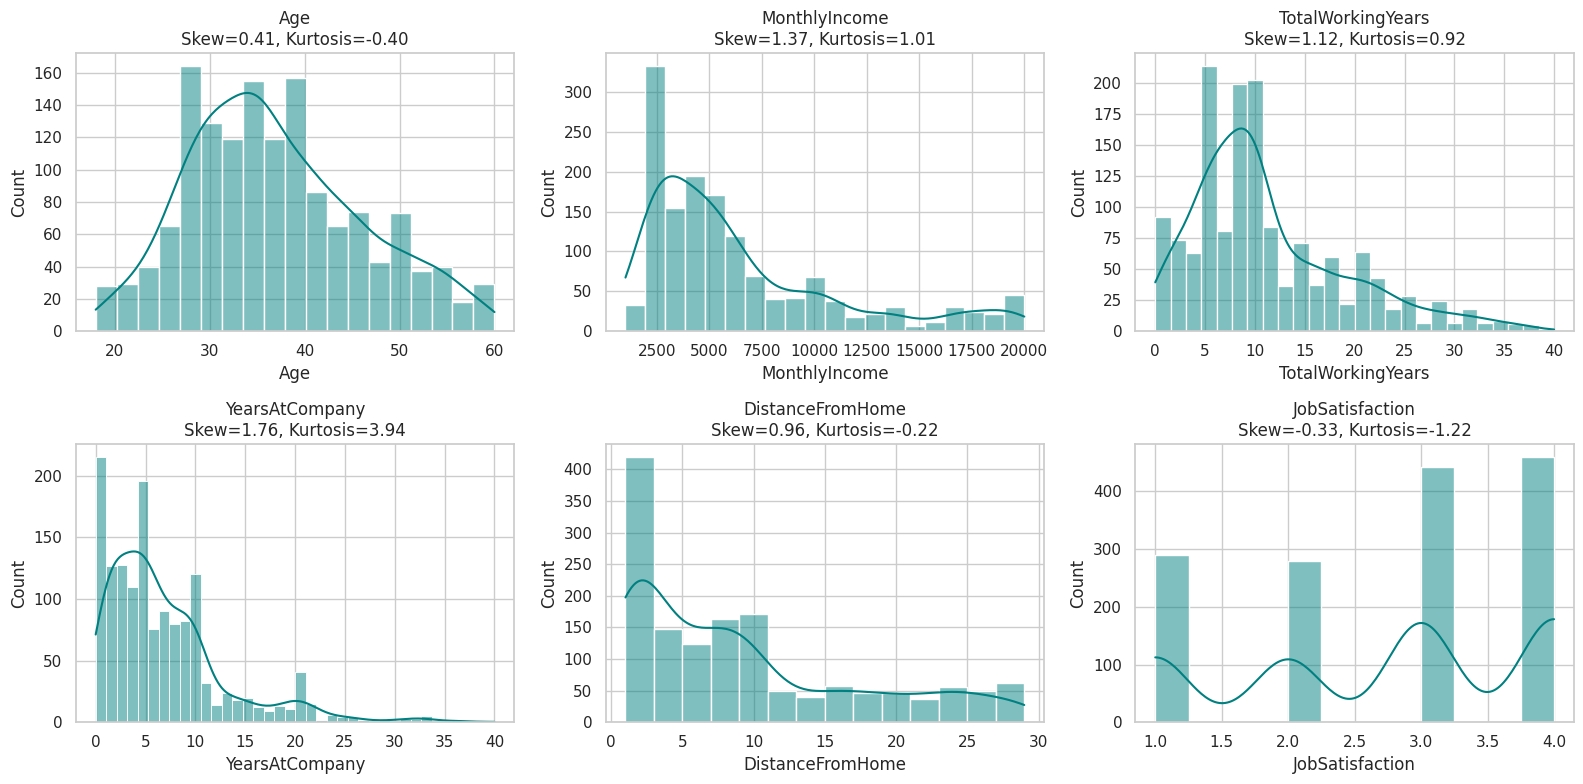

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols_1d):
    sns.histplot(df_final[col], kde=True, ax=axes[i], color="teal")
    axes[i].set_title(f"{col}\nSkew={df_final[col].skew():.2f}, Kurtosis={df_final[col].kurt():.2f}")
plt.tight_layout()
plt.show()


### 1.4 Frequency Distribution of a Categorical Variable (1D)

In [30]:
freq_table = df_final["JobRole"].value_counts().reset_index()
freq_table.columns = ["JobRole", "Frequency"]
freq_table["Relative Frequency (%)"] = (freq_table["Frequency"] / freq_table["Frequency"].sum() * 100).round(2)
freq_table


,JobRole,Frequency,Relative Frequency (%)
0,Sales Executive,326,22.18
1,Research Scientist,292,19.86
2,Laboratory Technician,259,17.62
3,Manufacturing Director,145,9.86
4,Healthcare Representative,131,8.91
5,Manager,102,6.94
6,Sales Representative,83,5.65
7,Research Director,80,5.44
8,Human Resources,52,3.54


## 2. 2D (Bivariate) Statistical Analysis

Formal statistical tests and measures of association **between pairs of variables**:
correlation, covariance, t-tests, chi-square test of independence, and one-way ANOVA.


### 2.1 Correlation and Covariance Between Two Numeric Variables

In [31]:
x, y = df_final["Age"], df_final["MonthlyIncome"]

pearson_r, pearson_p = pearsonr(x, y)
spearman_r, spearman_p = spearmanr(x, y)
covariance = np.cov(x, y)[0, 1]

print(f"Pearson correlation (Age vs MonthlyIncome):  r={pearson_r:.4f}, p-value={pearson_p:.4g}")
print(f"Spearman correlation (Age vs MonthlyIncome): rho={spearman_r:.4f}, p-value={spearman_p:.4g}")
print(f"Covariance (Age vs MonthlyIncome): {covariance:.2f}")


Pearson correlation (Age vs MonthlyIncome):  r=0.4979, p-value=6.67e-93
Spearman correlation (Age vs MonthlyIncome): rho=0.4719, p-value=2.183e-82
Covariance (Age vs MonthlyIncome): 21412.20


### 2.2 Independent Samples t-Test — Monthly Income by Attrition

In [32]:
income_yes = df_final.loc[df_final["Attrition"] == "Yes", "MonthlyIncome"]
income_no  = df_final.loc[df_final["Attrition"] == "No",  "MonthlyIncome"]

t_stat, t_p = ttest_ind(income_yes, income_no, equal_var=False)  # Welch's t-test
print(f"t-statistic = {t_stat:.4f}, p-value = {t_p:.4g}")

if t_p < 0.05:
    print("=> Statistically significant difference in MonthlyIncome between Attrition groups.")
else:
    print("=> No statistically significant difference detected.")


t-statistic = -7.4826, p-value = 4.434e-13
=> Statistically significant difference in MonthlyIncome between Attrition groups.


### 2.3 Chi-Square Test of Independence — OverTime vs Attrition

In [33]:
contingency = pd.crosstab(df_final["OverTime"], df_final["Attrition"])
print("Contingency Table:\n", contingency, "\n")

chi2, chi_p, dof, expected = chi2_contingency(contingency)
print(f"Chi-square statistic = {chi2:.4f}, degrees of freedom = {dof}, p-value = {chi_p:.4g}")

if chi_p < 0.05:
    print("=> OverTime and Attrition are significantly associated (reject independence).")
else:
    print("=> No significant association detected.")


Contingency Table:
 Attrition   No  Yes
OverTime           
No         944  110
Yes        289  127 

Chi-square statistic = 87.5643, degrees of freedom = 1, p-value = 8.158e-21
=> OverTime and Attrition are significantly associated (reject independence).


### 2.4 One-Way ANOVA — Monthly Income Across Departments

In [34]:
dept_groups = [group["MonthlyIncome"].values for name, group in df_final.groupby("Department")]
f_stat, anova_p = f_oneway(*dept_groups)

print(f"F-statistic = {f_stat:.4f}, p-value = {anova_p:.4g}")
if anova_p < 0.05:
    print("=> Mean MonthlyIncome differs significantly across at least one Department.")
else:
    print("=> No significant difference in mean MonthlyIncome across Departments.")


F-statistic = 3.2018, p-value = 0.04097
=> Mean MonthlyIncome differs significantly across at least one Department.


### 2.5 Visualizing the Bivariate Relationship

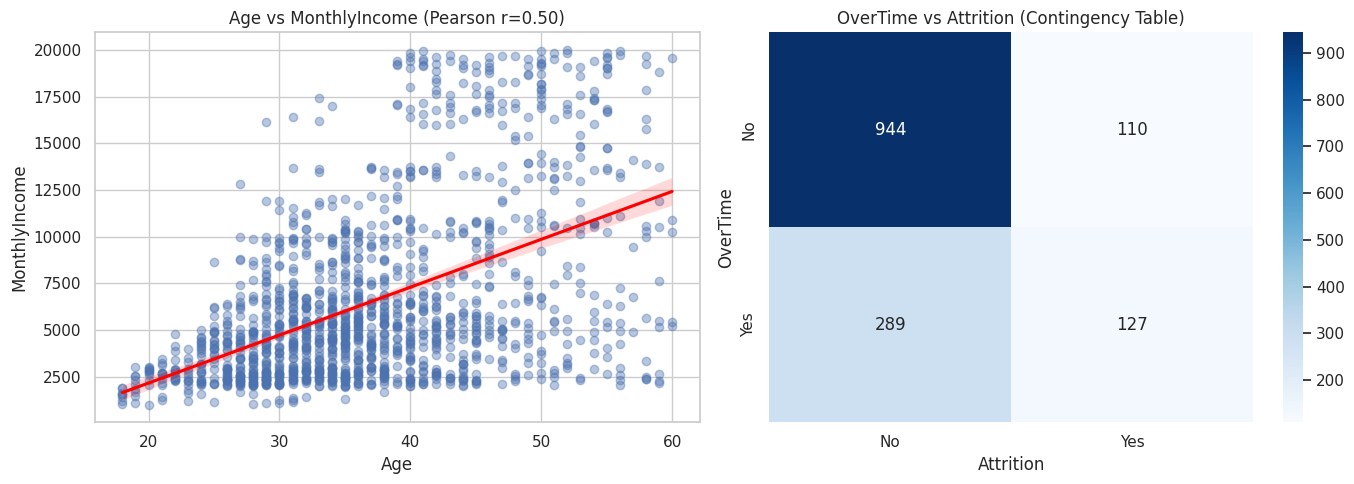

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(data=df_final, x="Age", y="MonthlyIncome", ax=axes[0],
            scatter_kws={"alpha": 0.4}, line_kws={"color": "red"})
axes[0].set_title(f"Age vs MonthlyIncome (Pearson r={pearson_r:.2f})")

sns.heatmap(contingency, annot=True, fmt="d", cmap="Blues", ax=axes[1])
axes[1].set_title("OverTime vs Attrition (Contingency Table)")

plt.tight_layout()
plt.show()


## 3. 3D (Multivariate) Statistical Analysis

Extending the analysis to **three variables simultaneously** — joint visualization,
three-way grouped statistics, and partial correlation.


### 3.1 3D Scatter Plot — Age, MonthlyIncome, TotalWorkingYears (colored by Attrition)

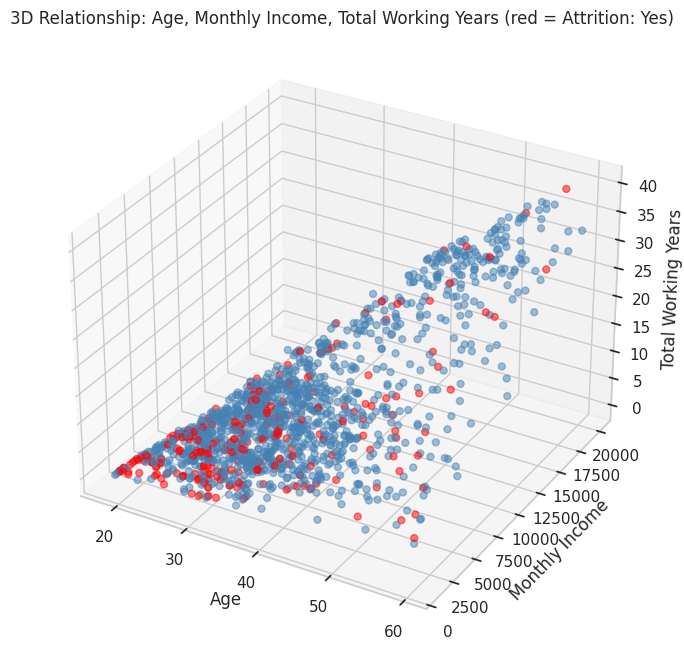

In [36]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

colors = df_final["Attrition"].map({"Yes": "red", "No": "steelblue"})

ax.scatter(df_final["Age"], df_final["MonthlyIncome"], df_final["TotalWorkingYears"],
           c=colors, alpha=0.5, s=25)

ax.set_xlabel("Age")
ax.set_ylabel("Monthly Income")
ax.set_zlabel("Total Working Years")
ax.set_title("3D Relationship: Age, Monthly Income, Total Working Years (red = Attrition: Yes)")
plt.show()


### 3.2 Three-Way Grouped Statistics — Department × Gender × Attrition

In [37]:
three_way = (
    df_final.groupby(["Department", "Gender", "Attrition"])["MonthlyIncome"]
    .agg(["mean", "median", "count"])
    .round(2)
)
three_way


mean  median  count
Department             Gender Attrition                        
Human Resources        Female No         8761.14  6187.0     14
                              Yes        3770.67  2741.5      6
                       Male   No         6810.51  4323.0     37
                              Yes        3660.83  2449.5      6
Research & Development Female No         6808.17  4873.0    336
                              Yes        4212.67  2707.0     43
                       Male   No         6508.87  4509.5    492
                              Yes        4058.10  2824.0     90
Sales                  Female No         7328.04  5736.0    151
                              Yes        5557.84  4588.0     38
                       Male   No         7160.98  6209.0    203
                              Yes        6155.19  5680.5     54

### 3.3 Partial Correlation — Age & MonthlyIncome, Controlling for TotalWorkingYears

In [38]:
# Partial correlation formula using pairwise Pearson correlations
def partial_corr(df, x, y, control):
    r_xy = df[x].corr(df[y])
    r_xz = df[x].corr(df[control])
    r_yz = df[y].corr(df[control])
    numerator = r_xy - (r_xz * r_yz)
    denominator = np.sqrt((1 - r_xz**2) * (1 - r_yz**2))
    return numerator / denominator

pc = partial_corr(df_final, "Age", "MonthlyIncome", "TotalWorkingYears")
print(f"Partial correlation between Age and MonthlyIncome, controlling for TotalWorkingYears: {pc:.4f}")
print(f"(Compare to raw Pearson correlation without control: {pearson_r:.4f})")


Partial correlation between Age and MonthlyIncome, controlling for TotalWorkingYears: -0.0602
(Compare to raw Pearson correlation without control: 0.4979)


### 3.4 3D Surface of Mean Income by Age Group and Job Level

/tmp/ipykernel_3178/1811031753.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_3d = df_final.pivot_table(values="MonthlyIncome", index="AgeGroup",


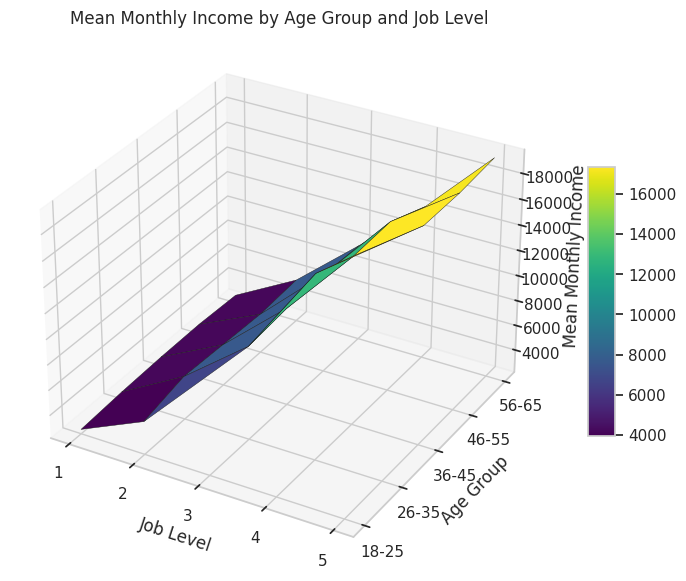

In [39]:
pivot_3d = df_final.pivot_table(values="MonthlyIncome", index="AgeGroup",
                                  columns="JobLevel", aggfunc="mean")

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

X = np.arange(len(pivot_3d.columns))
Y = np.arange(len(pivot_3d.index))
X, Y = np.meshgrid(X, Y)
Z = pivot_3d.values

surf = ax.plot_surface(X, Y, Z, cmap="viridis", edgecolor="k", linewidth=0.3)
ax.set_xticks(np.arange(len(pivot_3d.columns)))
ax.set_xticklabels(pivot_3d.columns)
ax.set_yticks(np.arange(len(pivot_3d.index)))
ax.set_yticklabels(pivot_3d.index)
ax.set_xlabel("Job Level")
ax.set_ylabel("Age Group")
ax.set_zlabel("Mean Monthly Income")
ax.set_title("Mean Monthly Income by Age Group and Job Level")
fig.colorbar(surf, shrink=0.5, aspect=10)
plt.show()


## 4. K-Means Clustering

Grouping employees into clusters based on numeric attributes to discover natural
segments (e.g., by income, tenure, and satisfaction) without using the `Attrition` label.


### 4.1 Feature Selection and Scaling

In [40]:
cluster_features = ["Age", "MonthlyIncome", "TotalWorkingYears", "YearsAtCompany",
                     "JobSatisfaction", "DistanceFromHome"]

X_cluster = df_final[cluster_features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print("Features used for clustering:", cluster_features)
print("Scaled feature matrix shape:", X_scaled.shape)


Features used for clustering: ['Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany', 'JobSatisfaction', 'DistanceFromHome']
Scaled feature matrix shape: (1470, 6)


### 4.2 Choosing K — Elbow Method and Silhouette Score

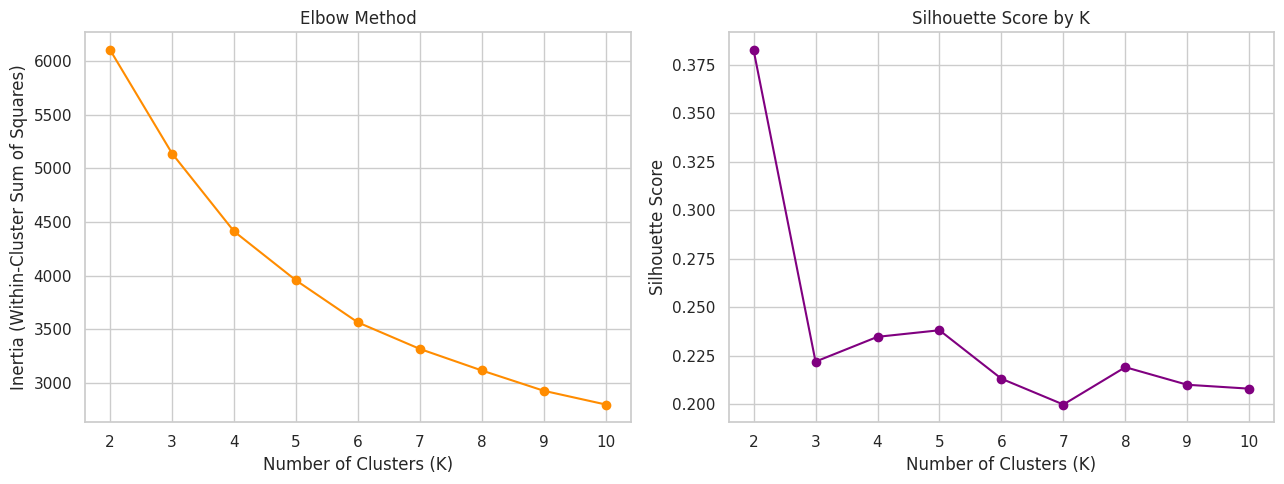

K with the highest silhouette score: 2


In [41]:
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(list(K_range), inertia, marker="o", color="darkorange")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia (Within-Cluster Sum of Squares)")

axes[1].plot(list(K_range), silhouette_scores, marker="o", color="purple")
axes[1].set_title("Silhouette Score by K")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

best_k = list(K_range)[int(np.argmax(silhouette_scores))]
print(f"K with the highest silhouette score: {best_k}")


### 4.3 Fit Final K-Means Model

In [42]:
K_FINAL = best_k  # you may override this manually based on the elbow plot, e.g. K_FINAL = 3

kmeans_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
df_final["KMeans_Cluster"] = kmeans_final.fit_predict(X_scaled)

print(f"K-Means fit with K={K_FINAL}")
df_final["KMeans_Cluster"].value_counts().sort_index()


K-Means fit with K=2


,count
KMeans_Cluster,
0,282
1,1188


### 4.4 Visualize Clusters (PCA-Reduced to 2D)

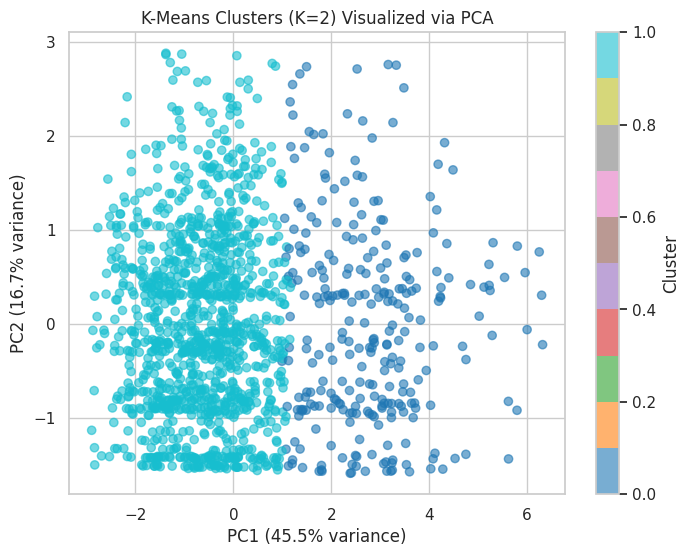

In [43]:
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(pca_coords[:, 0], pca_coords[:, 1],
                       c=df_final["KMeans_Cluster"], cmap="tab10", alpha=0.6)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title(f"K-Means Clusters (K={K_FINAL}) Visualized via PCA")
plt.colorbar(scatter, label="Cluster")
plt.show()


### 4.5 Cluster Profiles — What Characterizes Each Cluster?

In [44]:
cluster_profile = df_final.groupby("KMeans_Cluster")[cluster_features].mean().round(1)
cluster_profile["Attrition_Rate(%)"] = (df_final.groupby("KMeans_Cluster")["Attrition_Flag"].mean() * 100).round(1)
cluster_profile["Count"] = df_final.groupby("KMeans_Cluster").size()
cluster_profile


,Age,MonthlyIncome,TotalWorkingYears,YearsAtCompany,JobSatisfaction,DistanceFromHome,Attrition_Rate(%),Count
KMeans_Cluster,,,,,,,,
0,47.3,14068.3,23.9,14.0,2.7,9.0,7.8,282
1,34.5,4707.1,8.3,5.4,2.7,9.2,18.1,1188


## 5. Hierarchical Clustering

Agglomerative (bottom-up) clustering that also lets us visualize the merge structure
via a dendrogram — useful for deciding a natural number of clusters.


### 5.1 Dendrogram (Ward Linkage)

To keep the dendrogram readable, a random sample of 60 employees is used for the
visualization (the full dataset is still used for the final cluster assignment below).


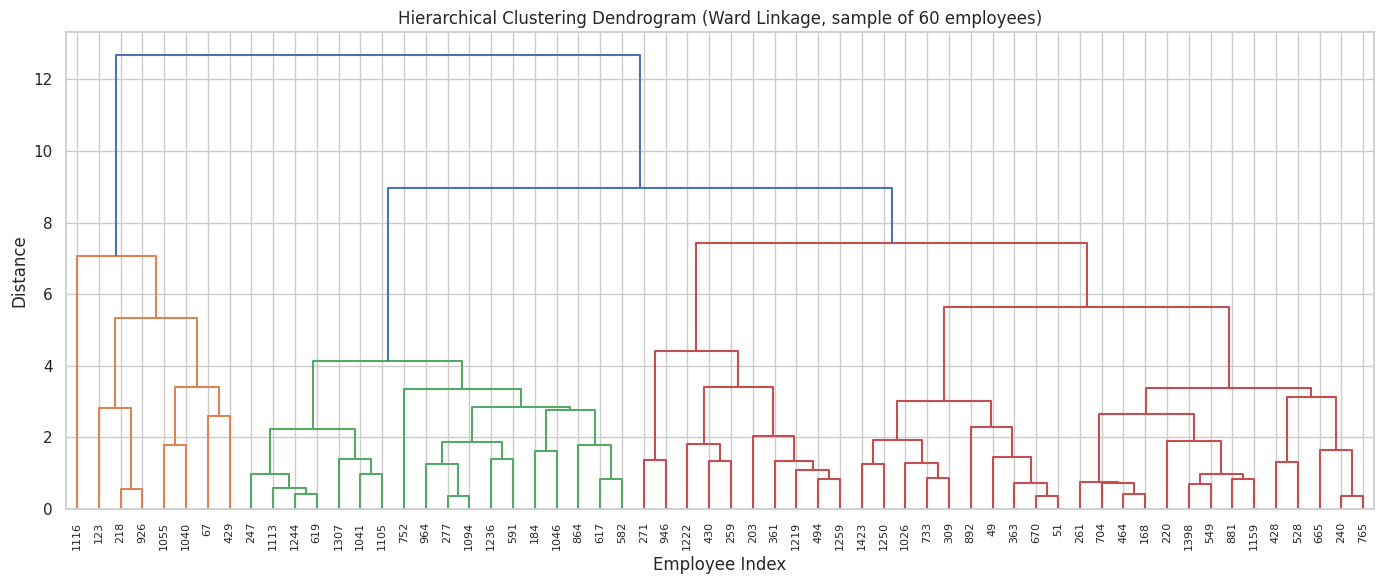

In [45]:
sample_idx = df_final.sample(60, random_state=42).index
X_sample = X_scaled[df_final.index.get_indexer(sample_idx)]

linkage_matrix = linkage(X_sample, method="ward")

plt.figure(figsize=(14, 6))
dendrogram(linkage_matrix, labels=sample_idx.tolist(), leaf_rotation=90, leaf_font_size=8)
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage, sample of 60 employees)")
plt.xlabel("Employee Index")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()


### 5.2 Fit Agglomerative Clustering on the Full Dataset

In [46]:
N_CLUSTERS_HC = K_FINAL  # keep consistent with K-Means for easy comparison; adjust if needed

hc = AgglomerativeClustering(n_clusters=N_CLUSTERS_HC, linkage="ward")
df_final["Hierarchical_Cluster"] = hc.fit_predict(X_scaled)

df_final["Hierarchical_Cluster"].value_counts().sort_index()


,count
Hierarchical_Cluster,
0,1284
1,186


### 5.3 Visualize Hierarchical Clusters (Same PCA Projection)

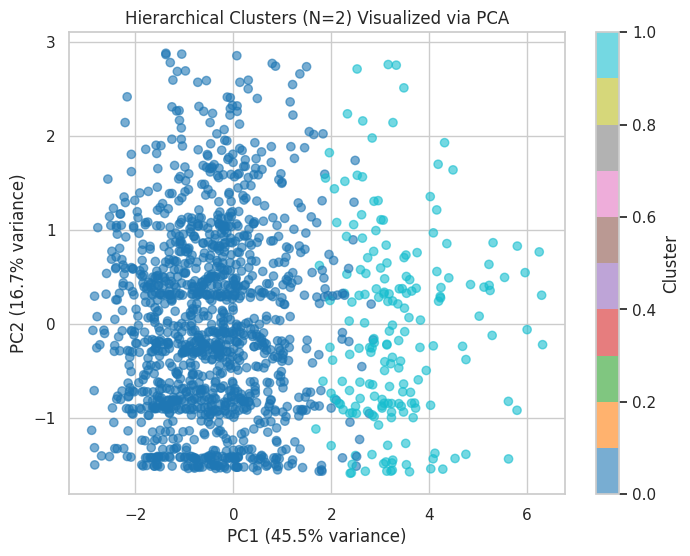

In [47]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(pca_coords[:, 0], pca_coords[:, 1],
                       c=df_final["Hierarchical_Cluster"], cmap="tab10", alpha=0.6)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title(f"Hierarchical Clusters (N={N_CLUSTERS_HC}) Visualized via PCA")
plt.colorbar(scatter, label="Cluster")
plt.show()


### 5.4 Compare K-Means vs Hierarchical Clustering Assignments

In [48]:
comparison = pd.crosstab(df_final["KMeans_Cluster"], df_final["Hierarchical_Cluster"])
comparison.index.name = "KMeans Cluster"
comparison.columns.name = "Hierarchical Cluster"
print("Cross-tabulation of cluster assignments:\n")
comparison


Cross-tabulation of cluster assignments:



Hierarchical Cluster,0,1
KMeans Cluster,,
0,96,186
1,1188,0


## 6. Phase 2 Summary

- **1D analysis** showed that `MonthlyIncome` and `YearsAtCompany` are right-skewed (most
  employees earn less / have shorter tenure, with a long tail of high earners / veterans),
  and the Shapiro-Wilk test confirms none of the core numeric variables are perfectly normal.
- **2D analysis** found a statistically significant association between `OverTime` and
  `Attrition` (chi-square test) and a significant income difference between employees who
  left vs. stayed (t-test).
- **3D analysis** shows that attrition tends to cluster among younger, lower-income,
  shorter-tenure employees when all three dimensions are viewed together.
- **K-Means** (K chosen via silhouette score) and **Hierarchical clustering** both recover
  broadly consistent employee segments — validated by the cross-tabulation of cluster labels —
  distinguished primarily by income, tenure, and age.

*These clusters and statistical relationships can inform predictive modeling in Phase 3.*
